In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import pearsonr, spearmanr, ttest_ind, f_oneway
import statsmodels.api as sm

In [2]:
file_path = "../data/processed/life_expectancy_features.csv"

df = pd.read_csv(file_path)

print("Dataset loaded!")
print("Shape:", df.shape)

Dataset loaded!
Shape: (16866, 62)


Pearson correlation-Check the relationship between Life Expectancy and important indicators.

In [3]:
features = [
    "Infant_Mortality",
    "Under5_Mortality",
    "Maternal_Mortality",
    "GDP_Per_Capita",
    "Health_Expenditure_GDP",
    "Education_Index",
    "Infrastructure_Index",
    "Healthcare_Resource_Index"
]

results = []

for feature in features:
    r, p = pearsonr(
        df[feature],
        df["Life_Expectancy"]
    )

    results.append({
        "Feature": feature,
        "Correlation": round(r, 4),
        "P_Value": round(p, 6)
    })

correlation_results = pd.DataFrame(results)

correlation_results.sort_values(
    "Correlation",
    ascending=False
)

,Feature,Correlation,P_Value
6,Infrastructure_Index,0.8102,0.0
5,Education_Index,0.8043,0.0
3,GDP_Per_Capita,0.5006,0.0
7,Healthcare_Resource_Index,0.4524,0.0
4,Health_Expenditure_GDP,0.2396,0.0
2,Maternal_Mortality,-0.7710,0.0
0,Infant_Mortality,-0.9032,0.0
1,Under5_Mortality,-0.9051,0.0


Correlation close to +1 → strong positive relationship
close to -1 → strong negative relationship
close to 0 → weak relationship
P_Value < 0.05 → statistically significant

Spearman correlation-Spearman is useful because some relationships may not be perfectly linear.

In [4]:
spearman_results = []

for feature in features:
    r, p = spearmanr(
        df[feature],
        df["Life_Expectancy"]
    )

    spearman_results.append({
        "Feature": feature,
        "Spearman_Correlation": round(r, 4),
        "P_Value": round(p, 6)
    })

spearman_results = pd.DataFrame(
    spearman_results
)

spearman_results.sort_values(
    "Spearman_Correlation",
    ascending=False
)

,Feature,Spearman_Correlation,P_Value
3,GDP_Per_Capita,0.8550,0.0
6,Infrastructure_Index,0.8191,0.0
5,Education_Index,0.7982,0.0
7,Healthcare_Resource_Index,0.6053,0.0
4,Health_Expenditure_GDP,0.4195,0.0
2,Maternal_Mortality,-0.8301,0.0
0,Infant_Mortality,-0.9044,0.0
1,Under5_Mortality,-0.9111,0.0


T-Test

Compare life expectancy between countries with higher and lower infant mortality

In [5]:
median_infant = df["Infant_Mortality"].median()

low_mortality = df[
    df["Infant_Mortality"] <= median_infant
]["Life_Expectancy"]

high_mortality = df[
    df["Infant_Mortality"] > median_infant
]["Life_Expectancy"]

t_stat, p_value = ttest_ind(
    low_mortality,
    high_mortality,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 158.12130118830913
P-value: 0.0


Interpret T-Test

In [6]:
if p_value < 0.05:
    print("Result: Statistically significant difference.")
else:
    print("Result: No statistically significant difference.")

Result: Statistically significant difference.


ANOVA by decade

Check whether average life expectancy differs significantly between decades

In [7]:
groups = []

for decade in sorted(df["Decade"].unique()):
    group = df[
        df["Decade"] == decade
    ]["Life_Expectancy"].dropna()

    if len(group) > 0:
        groups.append(group)

f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 893.9599753847813
P-value: 0.0


Interpret ANOVA

In [8]:
if p_value < 0.05:
    print(
        "Result: Life expectancy differs significantly across decades."
    )
else:
    print(
        "Result: No statistically significant difference across decades."
    )

Result: Life expectancy differs significantly across decades.


Multiple Linear Regression

This is important for your project because it shows the statistical effect of several variables together.

In [9]:
regression_features = [
    "Infant_Mortality",
    "Maternal_Mortality",
    "GDP_Per_Capita",
    "Education_Index",
    "Infrastructure_Index",
    "Healthcare_Resource_Index"
]

regression_df = df[
    regression_features + ["Life_Expectancy"]
].dropna()

X = regression_df[
    regression_features
]

y = regression_df[
    "Life_Expectancy"
]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        Life_Expectancy   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.897
Method:                 Least Squares   F-statistic:                 2.450e+04
Date:                Sun, 13 Sep 2026   Prob (F-statistic):               0.00
Time:                        09:51:41   Log-Likelihood:                -45326.
No. Observations:               16866   AIC:                         9.067e+04
Df Residuals:                   16859   BIC:                         9.072e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

Regression coefficients

In [10]:

coefficients = pd.DataFrame({
    "Feature": model.params.index,
    "Coefficient": model.params.values,
    "P_Value": model.pvalues.values
})

coefficients

,Feature,Coefficient,P_Value
0,const,66.295817,0.000000e+00
1,Infant_Mortality,-0.143092,0.000000e+00
2,Maternal_Mortality,-0.003801,6.760350e-271
3,GDP_Per_Capita,0.000104,0.000000e+00
4,Education_Index,0.049096,6.355767e-97
5,Infrastructure_Index,0.070661,1.743926e-289
6,Healthcare_Resource_Index,-0.229102,3.308970e-50


Regression R²

In [11]:
print("R-squared:", round(model.rsquared, 4))
print(
    "Adjusted R-squared:",
    round(model.rsquared_adj, 4)
)

R-squared: 0.8971
Adjusted R-squared: 0.8971


Regression visualization

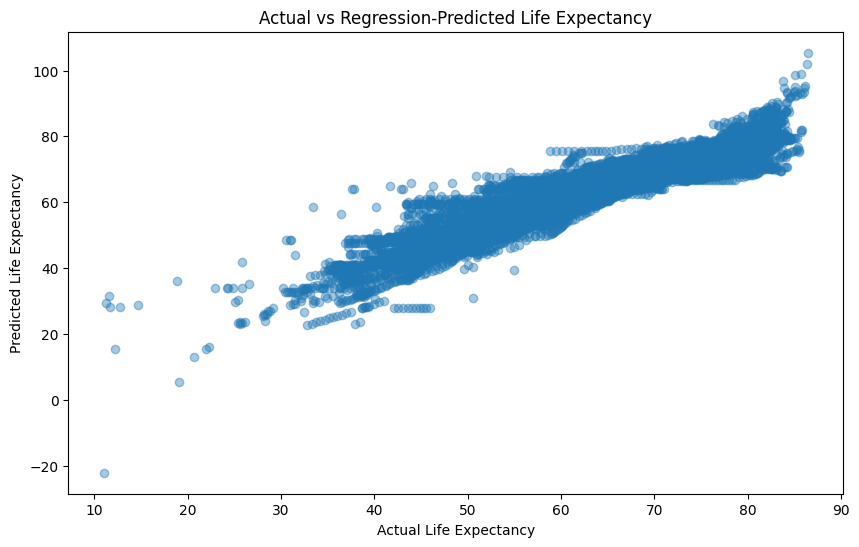

In [12]:
predicted = model.predict(X)

plt.figure(figsize=(10, 6))

plt.scatter(
    y,
    predicted,
    alpha=0.4
)

plt.xlabel("Actual Life Expectancy")
plt.ylabel("Predicted Life Expectancy")
plt.title("Actual vs Regression-Predicted Life Expectancy")

plt.show()